In [1]:
import cvxpy as cp
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import zap
from zap.importers.pypsa import load_pypsa_network, parse_buses
import os
from pathlib import Path
import pypsa
from zap.devices import ACLine
import pandas as pd
import geopandas as gpd
from copy import deepcopy

In [2]:
LOAD_SCALING_FACTOR = 1.27
GEN_SCALING_FACTOR = 1.24
# GEN_SCALING_FACTOR = 1
LINE_SCALING_FACTOR = 0.7
INVESTMENT_NODE_CANDS = [32, 82, 50, 18, 15, 22, 43, 14, 23, 20, 94, 65, 78] # This is already sorted by land cost
# INVESTMENT_NODE_CANDS = [0, 82, 50, 18, 15, 22, 43, 14, 23, 20, 45, 65, 78] # This is already sorted by land cost

In [3]:
def upsample_zap_devices(devices, factor=4, original_timesteps=24):
    """Upsample time-varying attributes of zap devices by repeating each timestep."""
    upsampled_zap_devices = []
    for dev in devices:
        upsampled_dev = dev.sample_time(original_timesteps*factor, original_timesteps)
        upsampled_zap_devices.append(upsampled_dev)

    return upsampled_zap_devices

In [4]:
HOME_PATH = os.environ.get("HOME")
PYPSA_NETW0RK_PATH = (
    HOME_PATH + "/zap_data/pypsa-networks/western_small/network_2023.nc"
)
pn = pypsa.Network(PYPSA_NETW0RK_PATH)
snapshots = pn.generators_t.p_max_pu.index
# snapshot_data = snapshots[5616:5640]  # 8/23/21 # hourly
snapshot_data = snapshots[5448:5472]  # 8/16/21 # hourly

INFO:pypsa.io:Imported network network_2023.nc has buses, carriers, generators, lines, links, loads, storage_units


## Get terminal/bus cost information for possible investment candidate nodes

In [5]:
buses, buses_to_index = parse_buses(pn) # buses_to_index is dict of "pyspa_bus_name": "zap_terminal"
index_to_bus = {idx: name for name, idx in buses_to_index.items()}
pypsa_bus_names = [index_to_bus[i] for i in INVESTMENT_NODE_CANDS]

b = pn.buses.copy()
gdf = gpd.GeoDataFrame(
    b, geometry=gpd.points_from_xy(b["x"], b["y"]), crs="EPSG:4326"
)

county_url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
counties = gpd.read_file(county_url)[["STATEFP","COUNTYFP","GEOID","NAME","STATE_NAME","geometry"]]

j = gpd.sjoin(gdf, counties.to_crs("EPSG:4326"), how="left", predicate="within")

pn.buses["county_fips"] = j["GEOID"]  # 5-digit FIPS
pn.buses["county_name"] = j["NAME"]
pn.buses["state_fips"]  = j["STATEFP"]
pn.buses["state_name"]  = j["STATE_NAME"]

selected_node_fips = pn.buses.loc[pypsa_bus_names, "county_fips"]
county_land_lut_df = pd.read_csv("county_land_lut.csv")

In [6]:
sel = selected_node_fips.rename("county_fips").to_frame()
bus_to_terminal = {bus: term for term, bus in index_to_bus.items()}
sel["terminal"] = sel.index.map(bus_to_terminal)
sel["county_fips"] = sel["county_fips"].astype(str).str.zfill(5)
county_land_lut_df["county_fips"] = county_land_lut_df["county_fips"].astype(str).str.zfill(5)

sel = sel.merge(
    county_land_lut_df,
    left_on="county_fips",
    right_on="county_fips",
    how="left",
)

terminal_cost = (
    sel.groupby("terminal")["land_usd2017_per_acre"]
      .first()   # or .mean(), depending on what you want
      .sort_index()
)

In [7]:
CAPITAL_COSTS = np.array(sel.land_usd2017_per_acre)

## Convert PyPSA network to Zap

In [8]:
pypsa_kwargs = {}
pypsa_net, pypsa_devices = load_pypsa_network(
    pn, snapshot_data, power_unit=1.0e3, cost_unit=100.0, **pypsa_kwargs
)
print("Before upsample:", pypsa_devices[3].capital_cost[0])

pypsa_devices = upsample_zap_devices(pypsa_devices, factor=4, original_timesteps=24)
print("After upsample:", pypsa_devices[3].capital_cost[0])


Dropping empty generators.
Before upsample: [0.28181126]
After upsample: [1.12724503]


## Helper to create devices for planning problem

In [9]:
def create_planning_devices(pypsa_devices, planning_devices_params_dict):
    num_nodes = planning_devices_params_dict["num_nodes"]
    investment_node_cands = planning_devices_params_dict["investment_node_cands"]
    gen_scaling_factor = planning_devices_params_dict["gen_scaling_factor"]
    load_scaling_factor = planning_devices_params_dict["load_scaling_factor"]
    line_scaling_factor = planning_devices_params_dict["line_scaling_factor"]
    dc_nominal_capacity = planning_devices_params_dict["dc_nominal_capacity"]
    capital_costs = planning_devices_params_dict["capital_costs"]
    workload_profile = planning_devices_params_dict["workload_profile"]
    pypsa_net = planning_devices_params_dict["pypsa_net"]
    pypsa_devices = planning_devices_params_dict["pypsa_devices"]

    pypsa_devices_dc = deepcopy(pypsa_devices)

    # Scale load, gen, and line capacities
    pypsa_devices_dc[1].load *= load_scaling_factor
    pypsa_devices_dc[0].dynamic_capacity *= gen_scaling_factor
    pypsa_devices_dc[3].nominal_capacity *= line_scaling_factor
    pypsa_devices_dc[3].nominal_capacity[168] = 0.5
    pypsa_devices_dc[3].nominal_capacity[176] = 0.5
    pypsa_devices_dc[3].nominal_capacity[49] = 0.3

    # Select which nodes to build at
    dc_terminals = np.array(investment_node_cands[:num_nodes])
    n_dc = len(dc_terminals)
    dc_capital_costs = capital_costs[:n_dc]

    # Build nominal capacities for DC loads
    if np.isscalar(dc_nominal_capacity):
        nominal_capacity = np.full(n_dc, dc_nominal_capacity)
    else:
        nominal_capacity = dc_nominal_capacity

    # Build DCLoad object
    dcloads = zap.DataCenterLoad(
        num_nodes=pypsa_net.num_nodes,
        terminal=dc_terminals,
        profiles=n_dc*[workload_profile],
        nominal_capacity=nominal_capacity,
        linear_cost=np.ones(n_dc) * 0,
        settime_horizon=96,
        capital_cost=dc_capital_costs
    )

    pypsa_devices_dc.append(dcloads)
    return pypsa_devices_dc


## Run and analyze single node injection

In [10]:
def node_price_summaries(prices, topk=5, q=(0.95, 0.99)):
    """
    prices: [N,T]
    Returns dict of [N,] summaries over time for each node.
    """
    prices = np.asarray(prices)

    out = {}
    # percentiles over time (axis=1)
    for qq in q:
        out[f"p{int(qq*100)}"] = np.quantile(prices, qq, axis=1)

    # mean over time
    out["mean"] = prices.mean(axis=1)

    # mean of top-k hours (per node)
    k = int(topk)
    out[f"mean_top{k}"] = np.sort(prices, axis=1)[:, -k:].mean(axis=1)

    # max (what you're already doing)
    out["max"] = prices.max(axis=1)

    return out


In [11]:
# This will add a DC at the cheapest land cost node
planning_devices_params_dict = {
    "num_nodes": 1,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": 1, # GW
    "capital_costs": 0*CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}


planning_devices = create_planning_devices(pypsa_devices, planning_devices_params_dict)
base_outcome = pypsa_net.dispatch(
    planning_devices[:-1], time_horizon=96, solver=cp.CLARABEL, add_ground=False
)
single_node_outcome = pypsa_net.dispatch(
    planning_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)

## Helper to run transmission planning instance

In [12]:
def run_planning_experiment(pypsa_net, pypsa_devices_dc, planning_exp_params_dict):
    trans_expansion_factor = planning_exp_params_dict["trans_expansion_factor"]
    op_obj_selector = planning_exp_params_dict["op_obj_selector"]
    lmp_metric = planning_exp_params_dict.get("lmp_metric", "meanmax")
    lmp_beta = planning_exp_params_dict.get("lmp_beta", 1.0)
    num_iters = planning_exp_params_dict["num_iters"]

    # Create dispatch layer
    xstar = zap.DispatchLayer(
        pypsa_net,
        pypsa_devices_dc,
        parameter_names={"line_capacity": (3, "nominal_capacity")},
        time_horizon=96,
        solver=cp.CLARABEL,
    )

    lower_bounds = {"line_capacity": pypsa_devices_dc[3].nominal_capacity}
    upper_bounds = {"line_capacity": trans_expansion_factor * pypsa_devices_dc[3].nominal_capacity}

    eta = {"line_capacity": pypsa_devices_dc[3].nominal_capacity}

    # Create objectives
    inv_obj = zap.planning.InvestmentObjective(pypsa_devices_dc, xstar)
    if op_obj_selector == "dispatch":
        op_obj = zap.planning.DispatchCostObjective(pypsa_net, pypsa_devices_dc)
    elif op_obj_selector == "lmp":
        op_obj = zap.planning.LMPObjective(pypsa_net, pypsa_devices_dc, lmp_metric=lmp_metric, lmp_beta = lmp_beta)

    P = zap.planning.PlanningProblem(
        operation_objective=op_obj,
        investment_objective=inv_obj,
        layer=xstar,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
    )

    P.extra_projections = {}

    cost = P(**eta, requires_grad=True)
    grad = P.backward()

    state = P.solve(num_iterations=num_iters, initial_state=eta)
    

    return state, P

## Run a transmission planning experiment

In [13]:
# planning_devices already includes the DC single node injection we want

planning_exp_params_dict = {
    "trans_expansion_factor": 1.05,
    "op_obj_selector": "dispatch", # "dispatch" or "lmp" or "line_util" or "delta_line_util" which defaults to meanmax
    "lmp_metric": "sumsmoothmax",
    "lmp_beta": 1000.0,
    "num_iters": 10
}

planning_state, P = run_planning_experiment(pypsa_net, planning_devices, planning_exp_params_dict)


No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
[0]

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
Starting iteration 1
{'line_capacity': tensor([[  1.1269],
        [  0.5893],
        [  2.2550],
        [  4.1712],
        [  0.4557],
        [  1.2710],
        [  1.3462],
        [  3.9662],
        [  1.5700],
        [  6.7565],
        [  2.6410],
        [  6.7790],
        [  3.1854],
        [  2.3098],
        [  3.9806],
        [  1.3708],
        [  4.7042],
        [  5.0320],
        [  4.5584],
        [  5.0796],
        [  3.4392],
        [  4.9322],
        [ -8.3385],
        [ -0.6834],
        [  0.6842],
        [  3.2999],
        [  4.4609],
        [  3.0631],
        [  8.8054],
        [  6.3342],
        [  4.8116],
        [  4.5941],
        [  1.8947],
      

In [14]:
# Simulate the dispatch outcome with the planned line capacities
planned_line_capacities = planning_state[0]["line_capacity"]
planned_devices = deepcopy(planning_devices)
planned_devices[3].nominal_capacity = planned_line_capacities

planned_outcome = pypsa_net.dispatch(
    planned_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)

In [50]:
planned_devices[4].power_capacity

array([[2.00000000e-03],
       [1.00000000e-03],
       [1.43000000e-02],
       [1.13000000e-01],
       [1.55000000e-01],
       [5.00000000e-02],
       [1.04000000e-01],
       [3.00000000e-02],
       [4.16000000e-02],
       [2.80000000e-01],
       [2.00000000e-03],
       [1.83900000e+00],
       [1.35000000e-01],
       [4.04500000e-01],
       [2.02900003e-01],
       [3.00000000e-03],
       [1.65560000e+00],
       [1.20000000e-02],
       [2.61500000e-01],
       [2.51700000e-01],
       [5.49000000e-02],
       [1.25000000e-01],
       [7.50000000e-02],
       [9.00000000e-02],
       [2.20000000e-01],
       [1.00000000e-03],
       [5.00000000e-02],
       [1.50000000e-02],
       [1.20000000e-02],
       [1.68000000e-01],
       [2.00000000e-02],
       [3.65000000e-01],
       [1.98000000e-01],
       [5.00000000e-02],
       [2.37800000e-01],
       [5.80000019e-03],
       [1.00000000e-03],
       [1.00000000e-03],
       [2.29200000e-01],
       [3.00000000e-02],


In [51]:
planned_devices[4].capital_cost

array([[ 5.81465634],
       [ 4.67159432],
       [10.46483995],
       [ 8.3612566 ],
       [ 5.16016114],
       [ 4.10006339],
       [ 8.49095989],
       [ 6.95771818],
       [ 4.1344102 ],
       [ 2.71818318],
       [ 3.38564969],
       [ 8.43735866],
       [ 8.38654558],
       [ 8.38124708],
       [ 7.05982759],
       [ 8.38654558],
       [ 6.64780521],
       [ 5.40982184],
       [ 6.72549958],
       [ 6.25323872],
       [ 8.13669598],
       [ 7.52924914],
       [ 9.81537298],
       [ 8.38654558],
       [ 4.10006339],
       [ 8.38654558],
       [ 8.38654558],
       [ 8.38654558],
       [ 8.38654558],
       [ 7.73166636],
       [ 4.10006339],
       [ 8.02640278],
       [ 7.75151118],
       [ 4.52871161],
       [ 9.43863842],
       [ 6.48965391],
       [ 5.81465634],
       [ 5.52889079],
       [ 8.33480358],
       [ 8.38654558],
       [ 5.07166598],
       [ 5.52889079],
       [ 8.36720807],
       [ 8.38241292],
       [ 8.38654558],
       [ 8

In [15]:
base_stats   = node_price_summaries(base_outcome.prices, topk=5)
single_stats = node_price_summaries(single_node_outcome.prices, topk=5)
dist_stats   = node_price_summaries(planned_outcome.prices, topk=5)

In [16]:
np.mean(dist_stats['max'])

0.5416138224485635

In [17]:
def line_util_metrics(flows_a, flows_b, line_nom_caps, thr=0.90):
    """
    Simple line-util comparison between scenario A and B.

    Args:
        flows_a: [L,T] line flows for scenario A
        flows_b: [L,T] line flows for scenario B
        line_nom_caps: [L,] nominal capacities
        thr: threshold for "critical" / near-binding (e.g., 0.90 or 0.95)

    Returns (dict):
        util_a, util_b: [L,T] utilizations
        peak_a, peak_b: [L]
        d_peak:         [L] = peak_a - peak_b   (positive => A has higher peak)
        hours_a, hours_b: [L] count of hours util>=thr
        d_hours:        [L] = hours_a - hours_b (positive => A has more near-binding hours)
        overload_a, overload_b: [L] mean exceedance above thr
        d_overload:     [L] = overload_a - overload_b
    """
    flows_a = np.asarray(flows_a)
    flows_b = np.asarray(flows_b)
    caps = np.asarray(line_nom_caps).reshape(-1)

    assert flows_a.shape == flows_b.shape
    L, T = flows_a.shape
    assert caps.shape[0] == L

    util_a = np.abs(flows_a) / caps[:, None]
    util_b = np.abs(flows_b) / caps[:, None]

    peak_a = util_a.max(axis=1)
    peak_b = util_b.max(axis=1)
    d_peak = peak_a - peak_b

    hours_a = (util_a >= thr).sum(axis=1)
    hours_b = (util_b >= thr).sum(axis=1)
    d_hours = hours_a - hours_b

    overload_a = np.maximum(util_a - thr, 0.0).mean(axis=1)
    overload_b = np.maximum(util_b - thr, 0.0).mean(axis=1)
    d_overload = overload_a - overload_b

    return {
        "util_a": util_a, "util_b": util_b,
        "peak_a": peak_a, "peak_b": peak_b, "d_peak": d_peak,
        "hours_a": hours_a, "hours_b": hours_b, "d_hours": d_hours,
        "overload_a": overload_a, "overload_b": overload_b, "d_overload": d_overload,
        "thr": thr
    }

def critical_lines_from_base(base_flows, single_flows, line_nom_caps, thr=0.90):
    """
    Step 1: define critical lines as those that become near-binding in the single-node case.
    We flag lines with peak utilization >= thr under single-node.

    Returns:
        crit_idx: indices of critical lines
        metrics: output of line_util_metrics(single, base, ...)
    """
    metrics = line_util_metrics(single_flows, base_flows, line_nom_caps, thr=thr)
    crit_idx = np.where(metrics["peak_a"] >= thr)[0]  # peak_a is single-node peak
    return crit_idx, metrics

In [41]:
##--- Usage ---##
line_nom_caps = planned_devices[3].nominal_capacity.squeeze()
planned_flows  = planned_outcome.power[3][1]   # [251,96]
base_flows    = base_outcome.power[3][1]          # [251,96]
threshold = 0.9

single_node_metrics = line_util_metrics(planned_flows, base_flows, line_nom_caps, thr=threshold)
print(f"Line-steps at threshold of {threshold}: {single_node_metrics['hours_a'].sum()}")

crit_idx, single_vs_base = critical_lines_from_base(
    base_flows=base_flows,
    single_flows=planned_flows,
    line_nom_caps=line_nom_caps,
    thr=threshold
)

print("num critical lines:", len(crit_idx))
# Now later you can evaluate distributed vs single (or distributed vs base) using line_util_metrics(...)
# dist_flows = dist_outcome.power[3][1]
# dist_vs_single = line_util_metrics(single_flows, dist_flows, line_nom_caps, thr=0.90)
# and then look at dist_vs_single["d_peak"][crit_idx], etc.


Line-steps at threshold of 0.9: 712
num critical lines: 15


In [19]:
base_outcome.prices.flatten()

array([0.43922211, 0.43922211, 0.43922212, ..., 0.13129716, 0.13129717,
       0.13129718])

Total Single Node Investment Cost: 115971.96
Total Transmission Investment Cost: 92587.97
Total Investment Cost: 208559.94
Dispatch Cost: 2264.64


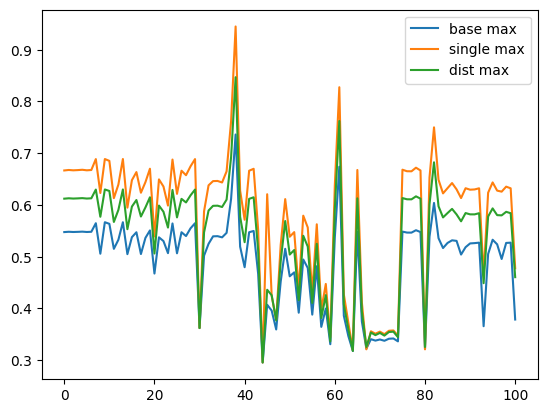

In [20]:
metric = "max" # mean, max, p95, p99, mean_top5
plt.plot(base_stats["p95"], label="base "+metric)
plt.plot(single_stats["p95"], label="single "+metric)
plt.plot(dist_stats["p95"], label="dist "+metric)
plt.legend()

dollars_per_mw_converter = 0.56
print(f"Total Single Node Investment Cost: {1000 * CAPITAL_COSTS[0] * dollars_per_mw_converter:.2f}")
print(f"Total Transmission Investment Cost: {P.get_inv_cost() * 100 * 1000:.2f}")
print(f"Total Investment Cost: {1000*CAPITAL_COSTS[0] * dollars_per_mw_converter + P.get_inv_cost() * 100 * 1000:.2f}")
print(f"Dispatch Cost: {P.get_op_cost():.2f}")

(array([ 8.,  9.,  8.,  5., 10., 51.,  6.,  2.,  1.,  1.]),
 array([0.2956815 , 0.35079709, 0.40591267, 0.46102826, 0.51614384,
        0.57125943, 0.62637501, 0.6814906 , 0.73660619, 0.79172177,
        0.84683736]),
 <BarContainer object of 10 artists>)

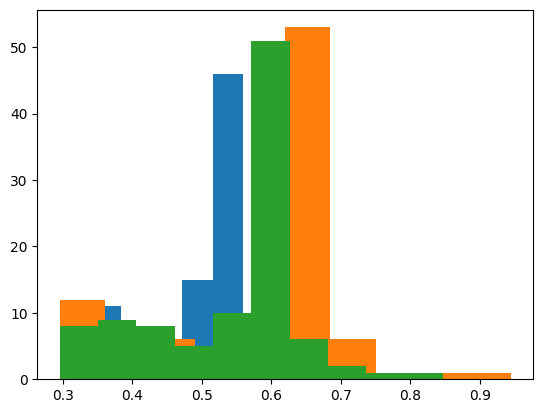

In [21]:
plt.hist(base_stats["p95"])
plt.hist(single_stats["p95"])
plt.hist(dist_stats["p95"])

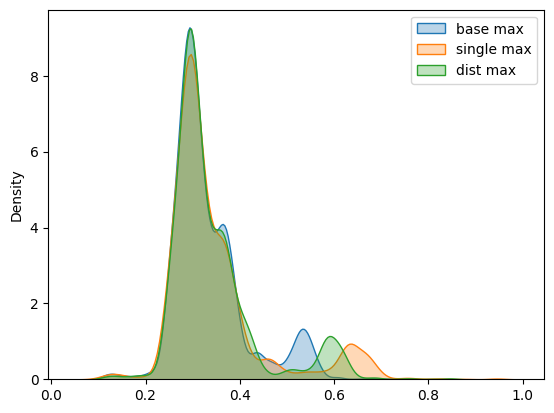

In [22]:
sns.kdeplot(base_outcome.prices.flatten(), label="base "+metric, fill=True, alpha=0.3)
sns.kdeplot(single_node_outcome.prices.flatten(), label="single "+metric, fill=True, alpha=0.3)
sns.kdeplot(planned_outcome.prices.flatten(), label="dist "+metric, fill=True, alpha=0.3)
plt.legend()

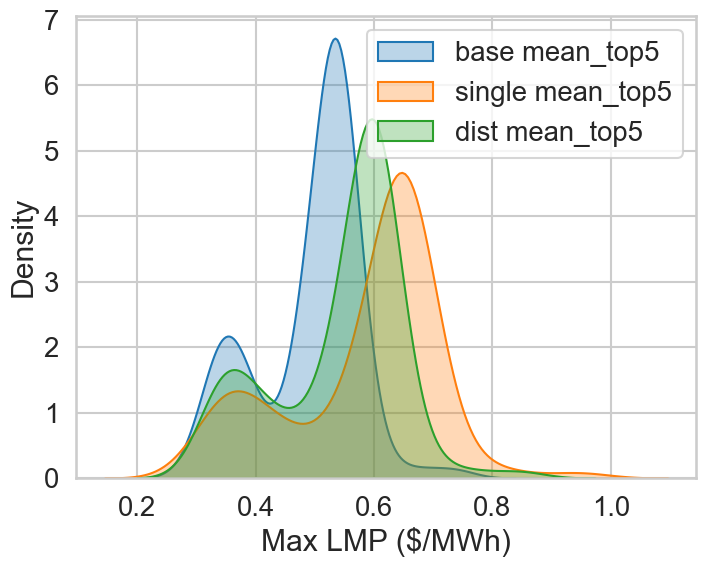

In [23]:
metric = "mean_top5"
sns.set_palette('tab10')
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.2)
plt.figure(figsize=(8,6))
sns.kdeplot(base_stats["mean_top5"], label="base "+metric, fill=True, alpha=0.3)
sns.kdeplot(single_stats["mean_top5"], label="single "+metric, fill=True, alpha=0.3)
sns.kdeplot(dist_stats["mean_top5"], label="dist "+metric, fill=True, alpha=0.3)
plt.xlabel("Max LMP ($/MWh)")
plt.legend()

In [24]:
line_nom_caps = planning_devices[3].nominal_capacity
line_planned_caps = planning_state[0]["line_capacity"]
line_diff = line_planned_caps - line_nom_caps

In [25]:
line_diff.shape

(251, 1)

In [26]:
np.sum(line_diff)

0.4694603053083134

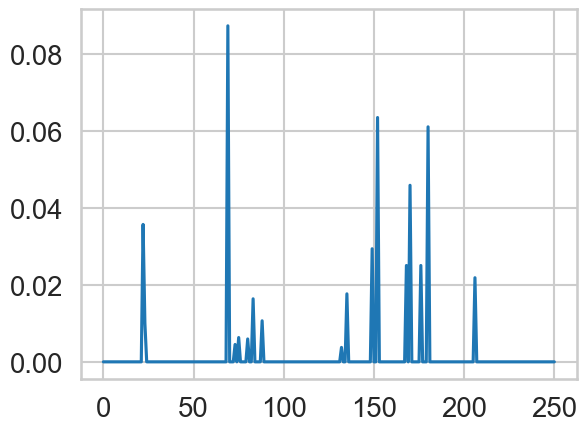

In [38]:
plt.plot(line_diff)

In [27]:
line_cap_costs = planning_devices[3].capital_cost

In [28]:
line_cap_costs 

array([[1.12724503],
       [0.58922785],
       [2.25604577],
       [4.46125791],
       [0.45258378],
       [1.26881689],
       [1.32977825],
       [3.92393437],
       [1.80683128],
       [6.1151844 ],
       [2.60314315],
       [7.10438314],
       [3.7062839 ],
       [2.30731506],
       [3.99851293],
       [1.38814131],
       [4.33542404],
       [6.34614712],
       [6.58808131],
       [5.29150609],
       [3.42974122],
       [7.66092793],
       [4.03240236],
       [3.02167179],
       [0.68480834],
       [4.07075452],
       [5.08780512],
       [3.23844791],
       [7.79431934],
       [6.24321253],
       [4.79883629],
       [4.58953854],
       [1.89289146],
       [3.61161364],
       [4.2840408 ],
       [0.65604222],
       [3.24544789],
       [1.96178616],
       [4.53547118],
       [1.19605194],
       [3.68992492],
       [6.22760258],
       [3.11493415],
       [5.0739847 ],
       [4.96306696],
       [4.99944507],
       [2.41784096],
       [4.015

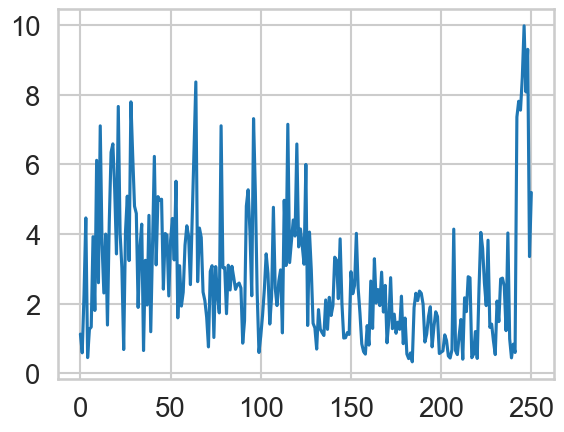

In [29]:
plt.plot(line_cap_costs)


In [30]:
print("len(snapshot_data):", len(snapshot_data))  # Should be 24
print("Raw pypsa capital_cost[0]:", pn.lines.capital_cost.iloc[0])
print("Zap capital_cost[0]:", planning_devices[3].capital_cost[0])

# Expected zap value:
expected = pn.lines.capital_cost.iloc[0] * (len(snapshot_data) / 8760) / 100
print("Expected zap:", expected)

len(snapshot_data): 24
Raw pypsa capital_cost[0]: 10286.110904608473
Zap capital_cost[0]: [1.12724503]
Expected zap: 0.28181125766050613


In [31]:
np.sum(line_cap_costs*100 * line_diff*1000) 

92587.99522224083

In [32]:
# Compute ACLine investment cost directly
line_inv = np.sum(planning_devices[3].capital_cost * line_diff)
print("ACLine inv (zap units):", line_inv)
print("ACLine inv ($):", line_inv * 100 * 1000)

ACLine inv (zap units): 0.9258799522224083
ACLine inv ($): 92587.99522224082


In [33]:
line_cap_costs

array([[1.12724503],
       [0.58922785],
       [2.25604577],
       [4.46125791],
       [0.45258378],
       [1.26881689],
       [1.32977825],
       [3.92393437],
       [1.80683128],
       [6.1151844 ],
       [2.60314315],
       [7.10438314],
       [3.7062839 ],
       [2.30731506],
       [3.99851293],
       [1.38814131],
       [4.33542404],
       [6.34614712],
       [6.58808131],
       [5.29150609],
       [3.42974122],
       [7.66092793],
       [4.03240236],
       [3.02167179],
       [0.68480834],
       [4.07075452],
       [5.08780512],
       [3.23844791],
       [7.79431934],
       [6.24321253],
       [4.79883629],
       [4.58953854],
       [1.89289146],
       [3.61161364],
       [4.2840408 ],
       [0.65604222],
       [3.24544789],
       [1.96178616],
       [4.53547118],
       [1.19605194],
       [3.68992492],
       [6.22760258],
       [3.11493415],
       [5.0739847 ],
       [4.96306696],
       [4.99944507],
       [2.41784096],
       [4.015

In [34]:
pn.lines.capital_cost

Line
0      10286.110905
1       5376.704100
10     20586.417643
100    40708.978456
101     4129.827011
           ...     
95     91033.913085
96     73716.758026
97     84886.083726
98     30596.779467
99     47369.260313
Name: capital_cost, Length: 251, dtype: float64

In [35]:
pn.lines.capital_cost.mean()

25383.967301140237

In [36]:
pn.lines.capital_cost.min()

3019.9336288778545

In [37]:
pn.lines.capital_cost.median()

21556.67253972882

## Run the experiment with distributed data centers

In [53]:
num_nodes = 10
planned_dc_capacities = np.array([0. , 0. , 0.2, 0. , 0. , 0. , 0.2, 0.2, 0.2, 0.2])

dist_planning_devices_params_dict = {
    "num_nodes": num_nodes,
    "investment_node_cands": INVESTMENT_NODE_CANDS,
    "gen_scaling_factor": GEN_SCALING_FACTOR,
    "load_scaling_factor": LOAD_SCALING_FACTOR,
    "line_scaling_factor": LINE_SCALING_FACTOR,
    "dc_nominal_capacity": planned_dc_capacities,
    "capital_costs": 0*CAPITAL_COSTS,
    "workload_profile": "load_profiles/example_inference_azure_conv.csv",
    "pypsa_net": pypsa_net,
    "pypsa_devices": pypsa_devices,
}
dist_planning_devices = create_planning_devices(pypsa_devices, dist_planning_devices_params_dict)


In [ ]:
# dist_planning_devices already includes the distributed DC injection we want 

dist_planning_exp_params_dict = {
    "trans_expansion_factor": 1.05,
    "op_obj_selector": "dispatch", # "dispatch" or "lmp" or "line_util" or "delta_line_util" which defaults to meanmax
    "lmp_metric": "sumsmoothmax",
    "lmp_beta": 1000.0,
    "num_iters": 10
}

dist_planning_state, dist_P = run_planning_experiment(pypsa_net, dist_planning_devices, planning_exp_params_dict)


No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
[0]

No capital cost or nominal capacity for device <class 'zap.devices.transporter.dc_line.DCLine'>
Starting iteration 1
{'line_capacity': tensor([[  1.1269],
        [  0.5894],
        [  2.2550],
        [  4.1102],
        [  0.4566],
        [  1.2713],
        [  1.3481],
        [  3.9697],
        [  1.6106],
        [  6.7462],
        [  2.6462],
        [  6.8094],
        [  3.2539],
        [  2.3101],
        [  3.9835],
        [  1.3741],
        [  4.6815],
        [  5.1600],
        [  4.8019],
        [  5.0983],
        [  3.4386],
        [  5.2099],
        [ -7.4262],
        [ -0.3255],
        [  0.6843],
        [  3.3893],
        [  4.5461],
        [  3.0870],
        [  8.5543],
        [  5.9920],
        [  4.8119],
        [  4.5947],
        [  1.8945],
      

In [70]:
# Simulate the dispatch outcome with the planned line capacities
dist_planned_line_capacities = dist_planning_state[0]["line_capacity"]
dist_planned_devices = deepcopy(dist_planning_devices)
dist_planned_devices[3].nominal_capacity = dist_planned_line_capacities

dist_planned_outcome = pypsa_net.dispatch(
    dist_planned_devices, time_horizon=96, solver=cp.CLARABEL, add_ground=False
)

In [71]:
actual_dist_stats  = node_price_summaries(dist_planned_outcome.prices, topk=5)

In [72]:
print(np.mean(actual_dist_stats["max"]))

0.5063119615478118


Total Single Node Investment Cost: 115971.96
Total Transmission Investment Cost: 92939.70
Total Investment Cost: 208911.67
Dispatch Cost: 2264.04


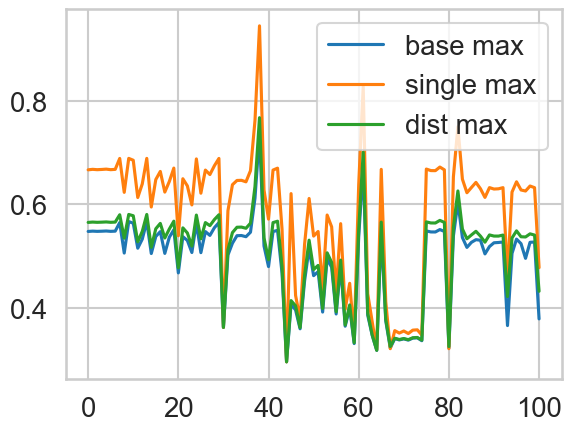

In [67]:
metric = "max" # mean, max, p95, p99, mean_top5
plt.plot(base_stats["p95"], label="base "+metric)
plt.plot(single_stats["p95"], label="single "+metric)
plt.plot(actual_dist_stats["p95"], label="dist "+metric)
plt.legend()

dollars_per_mw_converter = 0.56
print(f"Total Single Node Investment Cost: {1000 * CAPITAL_COSTS[0] * dollars_per_mw_converter:.2f}")
print(f"Total Transmission Investment Cost: {dist_P.get_inv_cost() * 100 * 1000:.2f}")
print(f"Total Investment Cost: {1000*CAPITAL_COSTS[0] * dollars_per_mw_converter + dist_P.get_inv_cost() * 100 * 1000:.2f}")
print(f"Dispatch Cost: {dist_P.get_op_cost():.2f}")

In [68]:
dist_line_nom_caps = dist_planning_devices[3].nominal_capacity
dist_line_planned_caps = dist_planning_state[0]["line_capacity"]
dist_line_diff = dist_line_planned_caps - dist_line_nom_caps

In [69]:
np.sum(dist_line_diff)

0.4656580628830845

In [76]:
##--- Usage ---##
dist_line_nom_caps = dist_planned_devices[3].nominal_capacity.squeeze()
dist_planned_flows  = dist_planned_outcome.power[3][1]   # [251,96]
base_flows    = base_outcome.power[3][1]          # [251,96]
threshold = 1.0

single_node_metrics = line_util_metrics(dist_planned_flows, base_flows, dist_line_nom_caps, thr=threshold)
print(f"Line-steps at threshold of {threshold}: {single_node_metrics['hours_a'].sum()}")

crit_idx, single_vs_base = critical_lines_from_base(
    base_flows=base_flows,
    single_flows=dist_planned_flows,
    line_nom_caps=dist_line_nom_caps,
    thr=threshold
)

print("num critical lines:", len(crit_idx))
# Now later you can evaluate distributed vs single (or distributed vs base) using line_util_metrics(...)
# dist_flows = dist_outcome.power[3][1]
# dist_vs_single = line_util_metrics(single_flows, dist_flows, line_nom_caps, thr=0.90)
# and then look at dist_vs_single["d_peak"][crit_idx], etc.


Line-steps at threshold of 1.0: 0
num critical lines: 0
